In [1]:
from src.utils import read_obs, save_figure
import seaborn as sns
from matplotlib import pyplot as plt
# Set global figure DPI
plt.rcParams["figure.dpi"] = 300  # Or any other value, e.g., 100, 150

/opt/conda/lib/python3.12/importlib/__init__.py:90: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  return _bootstrap._gcd_import(name[level:], package, level)


In [2]:
obs = read_obs("/root/capsule/data/adata/CaH_filtered_nuclei.2026-05-11.h5ad")

In [4]:
obs.shape

(686439, 81)

In [9]:
obs['ATAC_Non-nuclear_read_pairs'].isna().value_counts()

ATAC_Non-nuclear_read_pairs
True     573498
False    112941
Name: count, dtype: int64

In [3]:
obs_donor_path = (obs
.groupby("Donor ID")[["Braak", "Thal", "Overall AD neuropathological Change", "CPS", "CPS_6E10", "CPS_AT8", "percent AT8 positive area", "percent 6e10 positive area"]]
.first()
.rename(columns = {"Overall AD neuropathological Change":"ADNC", "percent 6e10 positive area":"6E10", "percent AT8 positive area":"AT8", "CPS_AT8":"$CPS_{AT8}$", "CPS_6E10":"$CPS_{6E10}$"})
)

/tmp/ipykernel_6566/294551108.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("Donor ID")[["Braak", "Thal", "Overall AD neuropathological Change", "CPS", "CPS_6E10", "CPS_AT8", "percent AT8 positive area", "percent 6e10 positive area"]]


In [4]:
obs_donor_path

,Braak,Thal,ADNC,CPS,$CPS_{6E10}$,$CPS_{AT8}$,AT8,6E10
Donor ID,,,,,,,,
H19.33.004,Braak IV,Thal 0,Not AD,0.000000,0.000000,0.000000,0.000001,0.000000
H20.33.001,Braak IV,Thal 2,Low,0.577213,0.349652,0.618921,0.066747,0.000000
H20.33.005,Braak IV,Thal 3,Intermediate,0.702125,0.738349,0.476388,0.004159,0.079647
H20.33.008,Braak V,Thal 4,High,0.961588,0.913234,0.823632,0.558316,1.113280
H20.33.011,Braak V,Thal 5,High,0.972877,0.972102,0.820284,0.282541,2.419150
H20.33.012,Braak III,Thal 1,Low,0.261753,0.195115,0.264122,0.001723,0.000000
H20.33.013,Braak IV,Thal 3,Intermediate,0.798131,0.732119,0.626150,0.013461,0.074065
H20.33.015,Braak V,Thal 3,Intermediate,0.675589,0.585716,0.566821,0.015323,0.008575
H20.33.016,Braak IV,Thal 4,Intermediate,0.814145,0.878570,0.529276,0.008250,0.571832


In [5]:
from scipy.stats import pearsonr, spearmanr
def cat2codes(x):
    if x.dtype == "category":
        return x.cat.codes.astype(int)
    else:
        return x

def annotate_corr(x, y, **kwargs):
    x = cat2codes(x)
    y = cat2codes(y)
    # drop rows where either value is missing
    mask = x.notna() & y.notna()
    r, p = spearmanr(x[mask], y[mask])
    ax = plt.gca()
    ax.annotate(f'$r_s$ = {r:.2f}\np = {p:.3f}',
                xy=(0.05, 0.95), xycoords='axes fraction',
                ha='left', va='top', fontsize=18,
                bbox=dict(boxstyle='round', fc='white', alpha=0.8))

/tmp/ipykernel_6594/2174590622.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation = 45, ha='right')
/tmp/ipykernel_6594/2174590622.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation = 30, ha = 'right')


Saved: /scratch/SupplementalFig1_OrdinalvsCPS.svg.svg
Saved: /scratch/SupplementalFig1_OrdinalvsCPS.svg.pdf


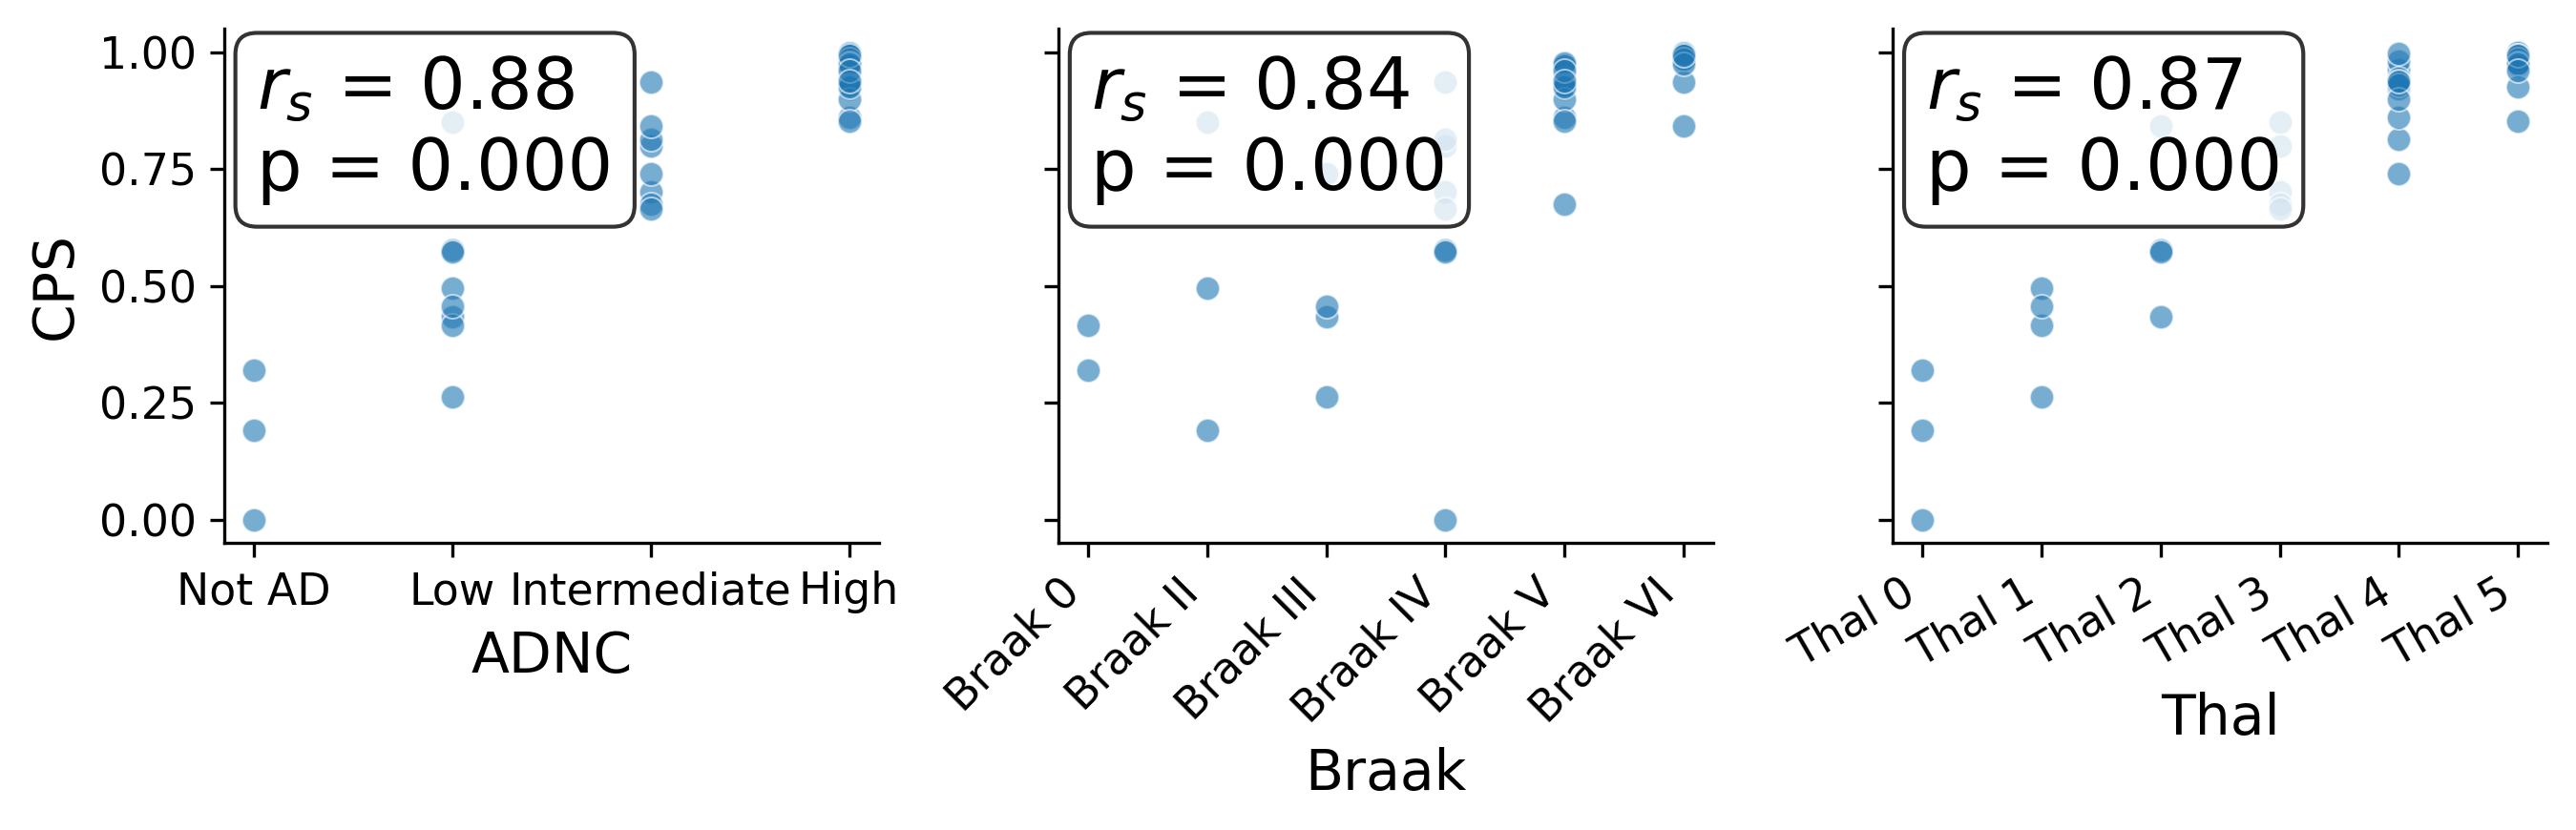

In [7]:
x_vars = ["CPS",]
y_vars = ["ADNC", "Braak", "Thal"]

g = sns.PairGrid(obs_donor_path, x_vars=y_vars, y_vars=x_vars, height=3,)
g.map(sns.scatterplot, alpha=0.6,)

g.map(annotate_corr)
for ax in g.axes.flat:
    ax.set_xlabel(ax.get_xlabel(), fontsize=14)
    if ax.get_xlabel() == "Braak":
        ax.set_xticklabels(ax.get_xticklabels(), rotation = 45, ha='right')
    elif ax.get_xlabel() == "Thal":
        ax.set_xticklabels(ax.get_xticklabels(), rotation = 30, ha = 'right')
    ax.set_ylabel(ax.get_ylabel(), fontsize=14)
    ax.tick_params(axis='both', labelsize=11)
plt.tight_layout()
save_figure(g, "/scratch/SupplementalFig1_OrdinalvsCPS.svg", dpi = 600)
plt.show()

## AT8 comparison plots

/tmp/ipykernel_6594/1994244065.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation = 45, ha='right')


Saved: /scratch/SupplementalFig1_AT8vPath.svg.svg
Saved: /scratch/SupplementalFig1_AT8vPath.svg.pdf


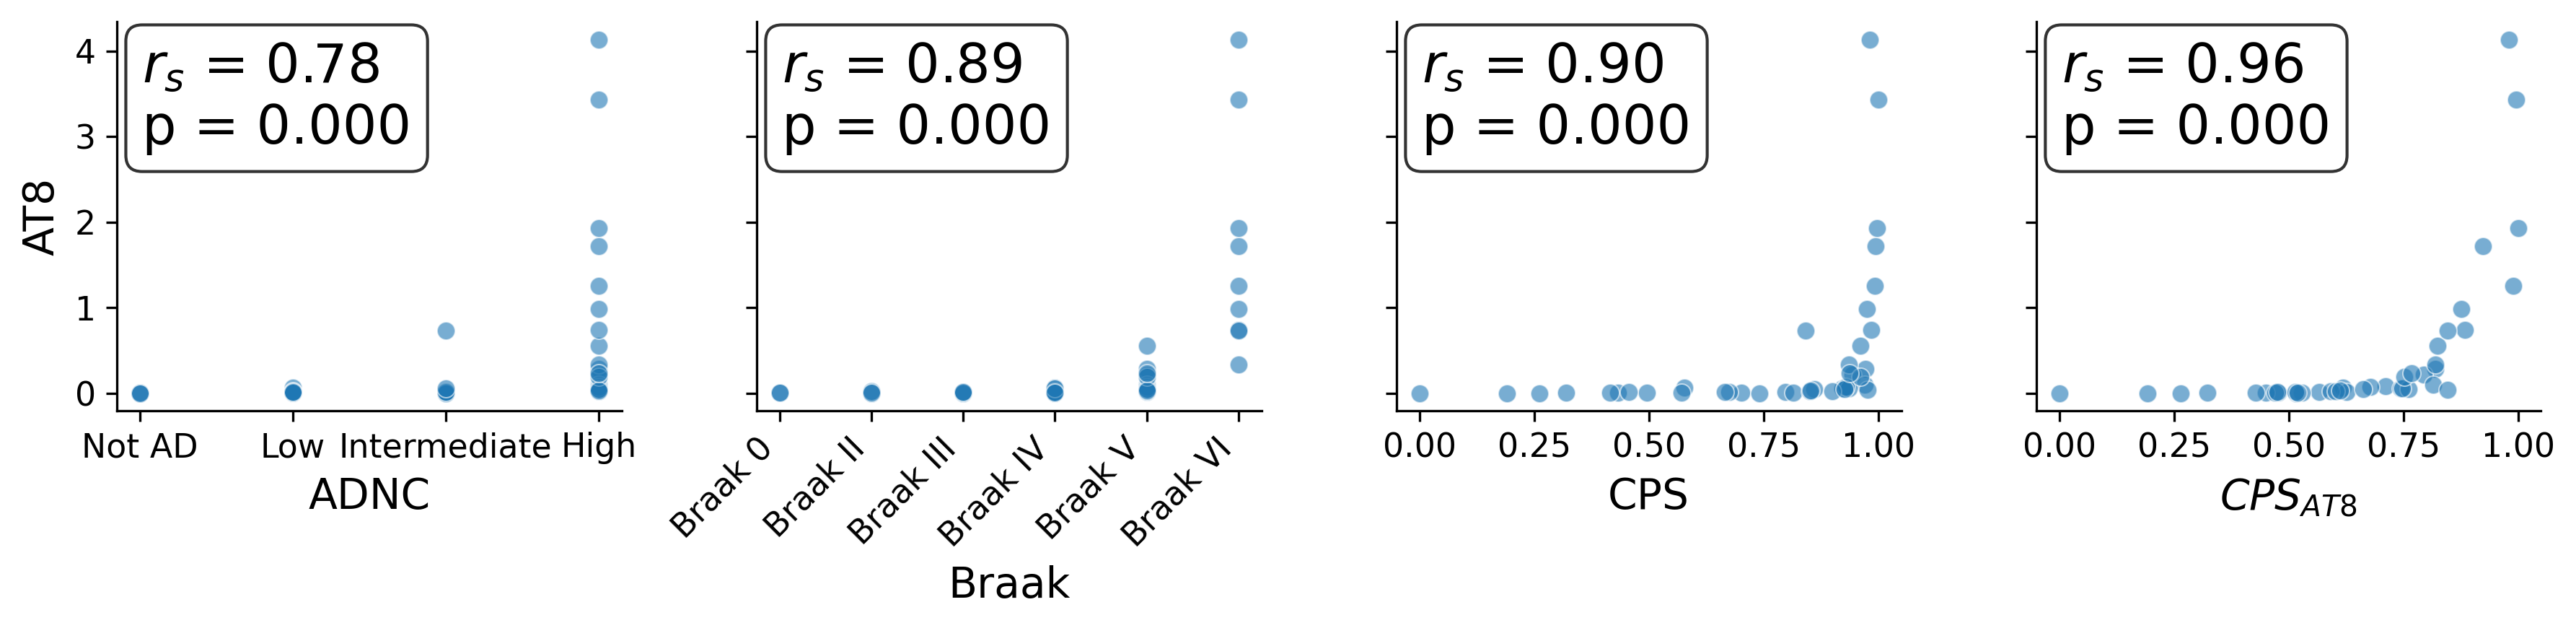

In [10]:
x_vars = ["AT8",]
y_vars = ["ADNC", "Braak", "CPS", "$CPS_{AT8}$"]

g = sns.PairGrid(obs_donor_path, x_vars=y_vars, y_vars=x_vars, height=3)
g.map(sns.scatterplot, alpha=0.6,)

g.map(annotate_corr)
for ax in g.axes.flat:
    ax.set_xlabel(ax.get_xlabel(), fontsize=14)
    if ax.get_xlabel() == "Braak":
        ax.set_xticklabels(ax.get_xticklabels(), rotation = 45, ha='right')
    ax.set_ylabel(ax.get_ylabel(), fontsize=14)
    ax.tick_params(axis='both', labelsize=11)
plt.tight_layout()
save_figure(g, "/scratch/SupplementalFig1_AT8vPath.svg", dpi = 600)
plt.show()

/tmp/ipykernel_6594/2972216843.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation = 30, ha='right')


Saved: /scratch/SupplementalFig1_6E10vPath.svg.svg
Saved: /scratch/SupplementalFig1_6E10vPath.svg.pdf


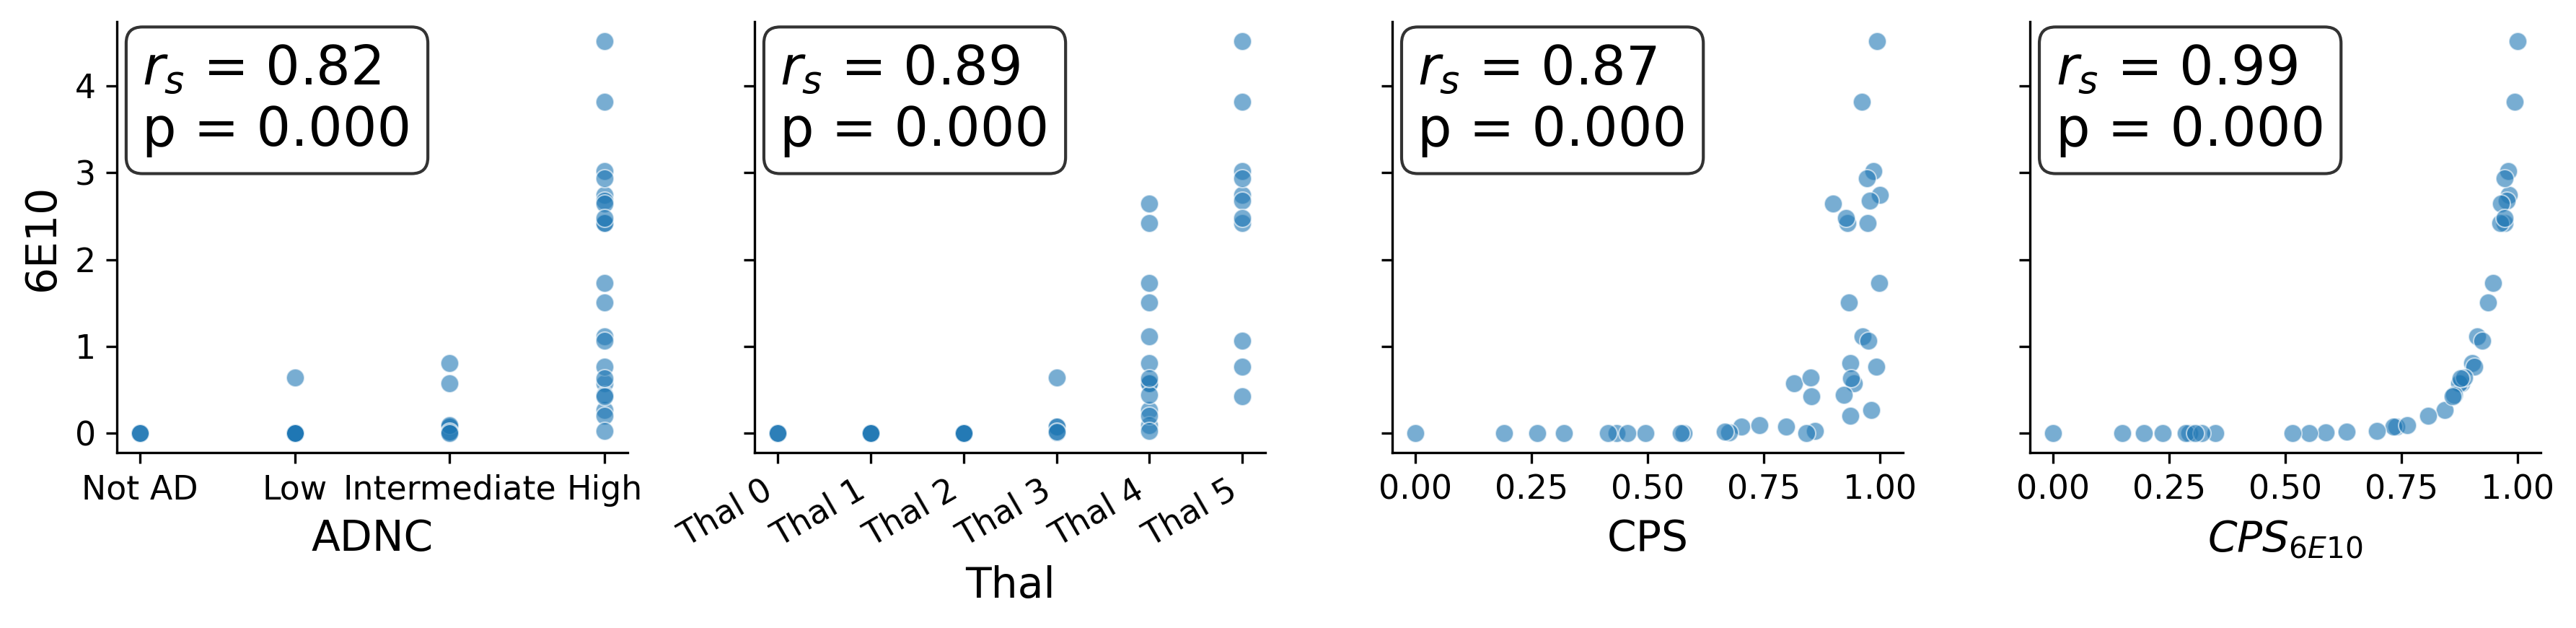

In [11]:

x_vars = ["6E10",]
y_vars = ["ADNC", "Thal", "CPS", "$CPS_{6E10}$"]

g = sns.PairGrid(obs_donor_path, x_vars=y_vars, y_vars=x_vars, height=3, )
g.map(sns.scatterplot, alpha=0.6,)

g.map(annotate_corr)
for ax in g.axes.flat:
    ax.set_xlabel(ax.get_xlabel(), fontsize=14)
    if ax.get_xlabel() == "Thal":
        ax.set_xticklabels(ax.get_xticklabels(), rotation = 30, ha='right')
    ax.set_ylabel(ax.get_ylabel(), fontsize=14)
    ax.tick_params(axis='both', labelsize=11)
plt.tight_layout()
save_figure(g, "/scratch/SupplementalFig1_6E10vPath.svg", dpi = 600)
plt.show()